# SIMULACIONES DIEGOD

In [2]:
### LIBRERÍAS ################################
 
import numpy as np
import matplotlib.pyplot as plt


### Simulacion 1: Masa efectivas constantes

Qué pasa cuando aumentamos por igual las masas efectivas de todas las regiones.
El Simulacion1.txt tiene la posición en energía del primer pico de transmisión para varias masas efectivas y a qué valor de masas corresponde.


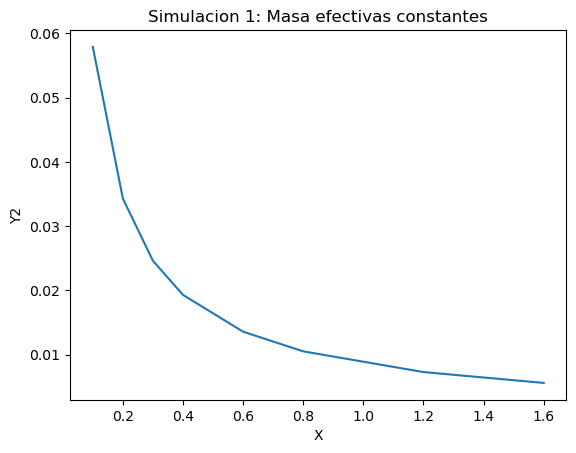

In [4]:
# Load data from the file, skipping the first row (headers)
data = np.loadtxt('prueba_masasefectivas/simulacion1.txt', skiprows=1)

# Plot X (first column) vs Y2 (second column)
plt.plot(data[:, 0], data[:, 1])
plt.xlabel('X')
plt.ylabel('Y2')
plt.title('Simulacion 1: Masa efectivas constantes')
plt.show()

Power-law fit: B = 0.0091296449697992 a = 0.8057889320483627


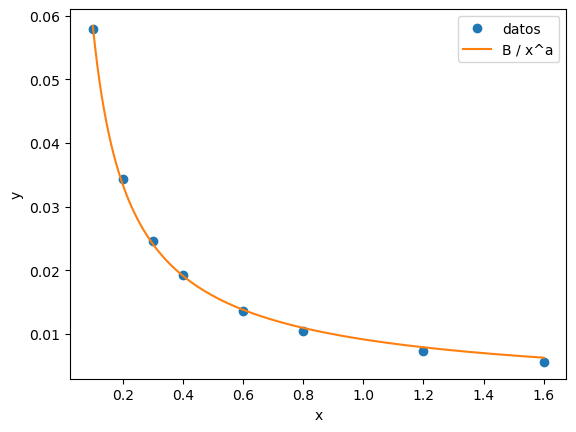

In [11]:
import scipy.optimize as opt

x = data[:, 0]
y = data[:, 1]

def power_func(x, B, a):
    return B / (x**a)

popt_pow, pcov_pow = opt.curve_fit(power_func, x, y, p0=(1.0, 1.0), bounds=(0, np.inf))

print("Power-law fit: B =", popt_pow[0], "a =", popt_pow[1])

x_fit = np.linspace(x.min(), x.max(), 200)
plt.plot(x, y, 'o', label='datos')
plt.plot(x_fit, power_func(x_fit, *popt_pow), label='B / x^a')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

### Simulacion 2:

Ahora ponemos las barreras desplazadas una energía 'A'. La configuración inicial es 0-0.4-0-0.4-0, luego puede ser 0.2-0.6-0.2-0.6-0.2, por ejemplo. Datos guardados en simulacion2.txt

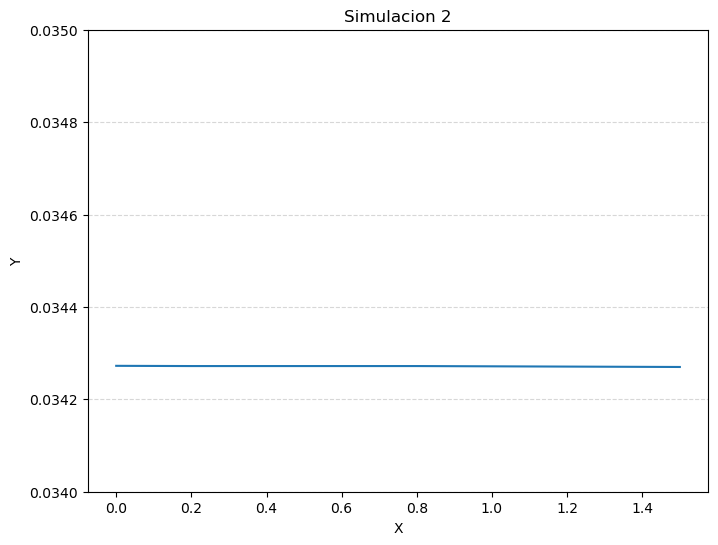

In [22]:
# Load data from simulacion2.txt, skipping the first row
data2 = np.loadtxt('prueba_masasefectivas/simulacion2.txt', skiprows=1)

# Extract x as first column, y as abs difference between first and second columns
x = data2[:, 0]
y = np.abs(data2[:, 0] - data2[:, 1])

# Plot using yticks to control the Y-axis scale / tick positions
plt.figure(figsize=(8, 6))
plt.plot(x, y)
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Simulacion 2')

# Force the Y axis to start at 0.1 and show ticks from 0.1 up to the max value

plt.ylim(0.034, 0.035)

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

Como vemos, es cte. Confirmamos relación lineal, ajustar el 0 no tiene ningún beneficio, se trabaja con barreras de potencial.